In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loading the Dataset

In [3]:
data=pd.read_excel("Global Superstore.xlsx")


In [5]:
data.info() #Checking the basic info of the data .

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [4]:
pd.set_option('display.max_columns' , None) # used for displaying max columns

In [5]:
data.head() #displays the first give rows of the data.

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,NaN,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,NaN,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,NaN,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [10]:
data.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [13]:
data.duplicated().sum()

np.int64(0)

In [14]:
data['Row ID'].duplicated().sum()

np.int64(0)

# Cleaning the Dataset

In [6]:
data.fillna({'Postal Code':111}  , inplace = True) #filling the 41296 null columns of postal code to default value say 111.

In [16]:
#We dont have any duplicates to remove (Checked above).


# Adding new columns for making Analysis easier

In [7]:
data['Year']=0
data['Month']=0
data['Quarter']='test'

In [8]:
for i in range(0 , len(data) , 1):
    data.loc[i , 'Year']=data.loc[i , 'Order Date'].year   #filling the Year column

In [9]:
for i in range(0 , len(data) , 1):
    data.loc[i , 'Month']=data.loc[i , 'Order Date'].month  #filling the Month column

In [10]:
for i in range(0 , len(data) , 1):              
    if data.loc[i , 'Month'] <=3:
        data.loc[i , 'Quarter']='Q1'
    elif data.loc[i , 'Month'] <=6:
        data.loc[i , 'Quarter']='Q2'
    elif data.loc[i , 'Month'] <=9:
        data.loc[i , 'Quarter']='Q3'
    else:
        data.loc[i , 'Quarter']='Q4'   #filling the quarter column

In [31]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Year,Month,Quarter
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,2012,7,Q3
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,111.0,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2013,2,Q1
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,111.0,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,2013,10,Q4
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,111.0,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,2013,1,Q1
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,111.0,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,2013,11,Q4


# Calculation of KPIs(Key Performance Indicator)

In [11]:
total_sales=data['Sales'].sum() #can also be done using for loops(loc method)

In [12]:
total_profit=data['Profit'].sum()


In [13]:
total_orders=data['Order ID'].nunique()

In [14]:
total_customers=data['Customer ID'].nunique()

In [15]:
total_unitsold=data['Quantity'].sum()

In [48]:
total_products=data['Product ID'].nunique()

# Calculating Sales Year and Quarter wise

In [20]:
grouped=data.groupby(['Year' , 'Quarter'])['Sales'].sum().reset_index()

In [21]:
grouped

,Year,Quarter,Sales
0,2011,Q1,3.357800e+05
1,2011,Q2,4.788710e+05
2,2011,Q3,6.133064e+05
3,2011,Q4,8.314935e+05
4,2012,Q1,3.993677e+05
5,2012,Q2,6.255929e+05
6,2012,Q3,7.377689e+05
7,2012,Q4,9.147092e+05
8,2013,Q1,5.650196e+05
9,2013,Q2,8.348395e+05


In [28]:
for i in range(len(grouped)):
    grouped.loc[i , 'New']=grouped.loc[i , 'Year'].astype(str) + " " + grouped.loc[i , 'Quarter']

In [29]:
grouped

,Year,Quarter,Sales,New
0,2011,Q1,3.357800e+05,2011 Q1
1,2011,Q2,4.788710e+05,2011 Q2
2,2011,Q3,6.133064e+05,2011 Q3
3,2011,Q4,8.314935e+05,2011 Q4
4,2012,Q1,3.993677e+05,2012 Q1
5,2012,Q2,6.255929e+05,2012 Q2
6,2012,Q3,7.377689e+05,2012 Q3
7,2012,Q4,9.147092e+05,2012 Q4
8,2013,Q1,5.650196e+05,2013 Q1
9,2013,Q2,8.348395e+05,2013 Q2


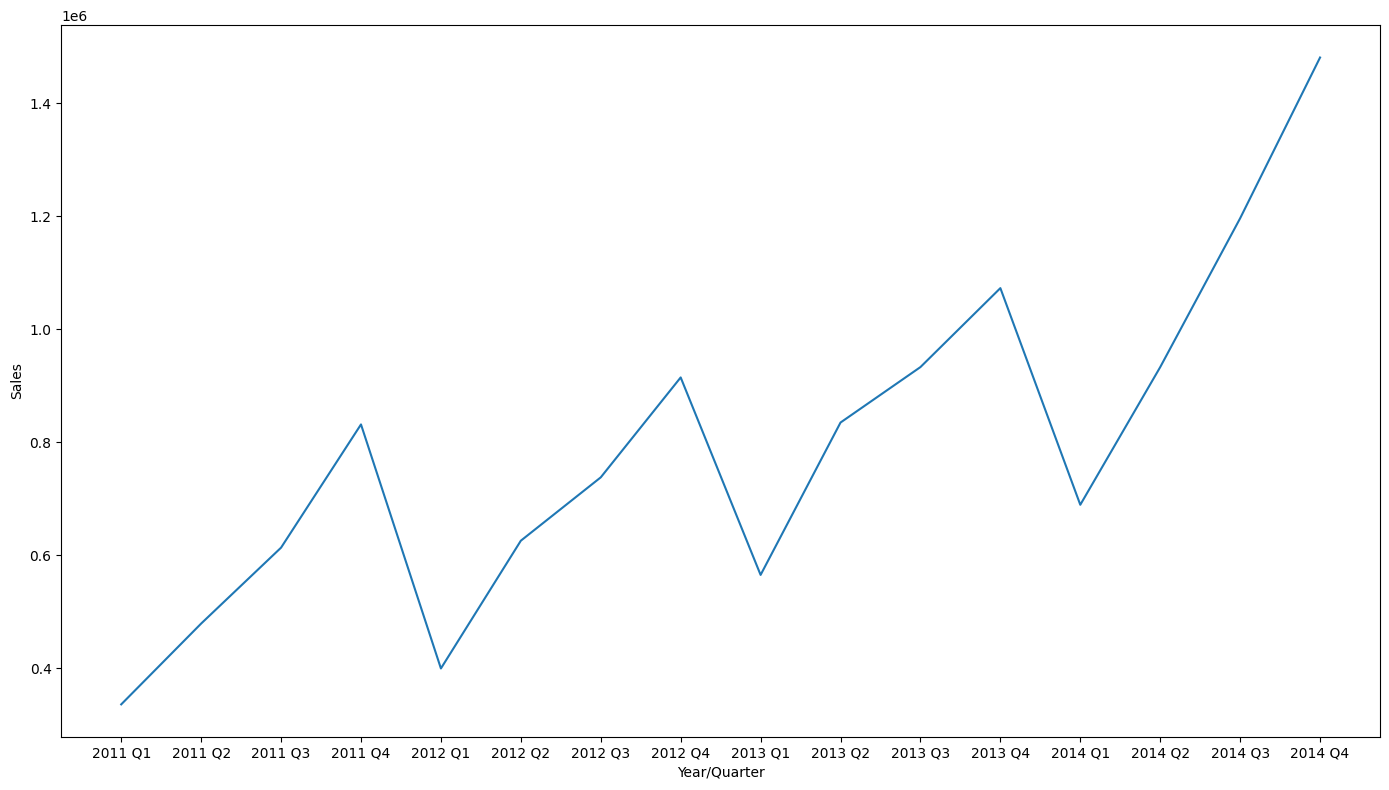

In [36]:
plt.figure(figsize=(14,8))
graph1=plt.plot(grouped['New'] , grouped['Sales'])
plt.xlabel("Year/Quarter")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


# Calculating Sales by Market

In [43]:
smark=data.groupby('Market')['Sales'].sum().reset_index()

In [44]:
smark

,Market,Sales
0,APAC,3.585744e+06
1,Africa,7.837732e+05
2,Canada,6.692817e+04
3,EMEA,8.061613e+05
4,EU,2.938089e+06
5,LATAM,2.164605e+06
6,US,2.297201e+06


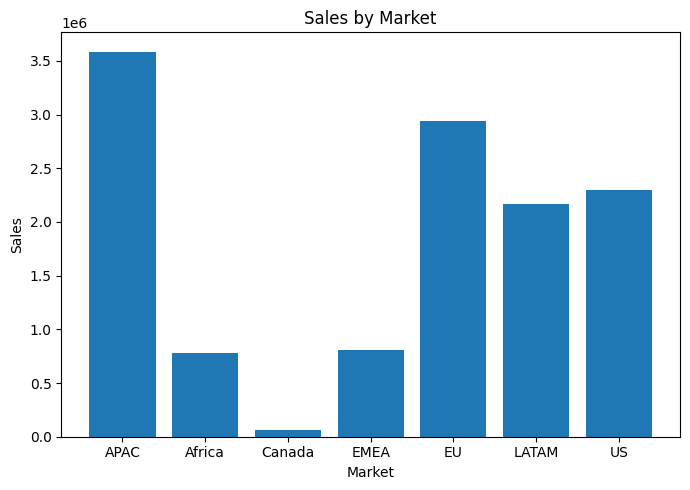

In [91]:
plt.figure(figsize=(7,5))
graph2=plt.bar(smark['Market'] , smark['Sales'])
plt.xlabel('Market')
plt.ylabel('Sales')
plt.title('Sales by Market')
plt.tight_layout()

plt.show()

# Calculating Sales by Category

In [47]:
scat=data.groupby('Category')['Sales'].sum().reset_index()

In [48]:
scat

,Category,Sales
0,Furniture,4.110874e+06
1,Office Supplies,3.787070e+06
2,Technology,4.744557e+06


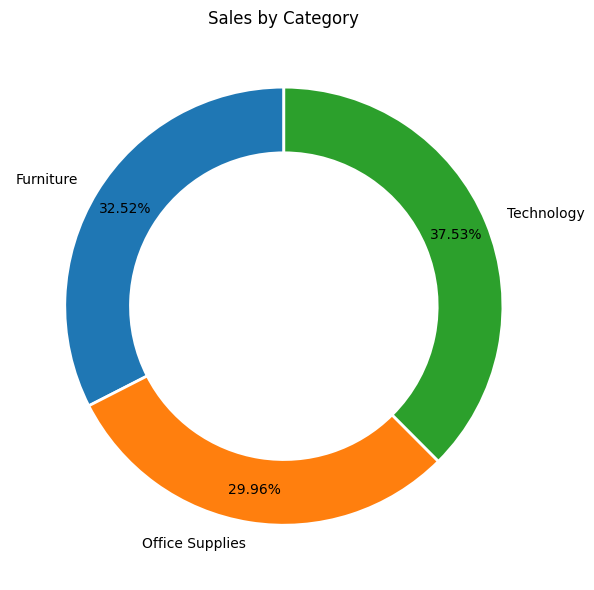

In [94]:
plt.figure(figsize=(12,6))


labels = ['Furniture' , 'Office Supplies' , 'Technology']
plt.pie(scat['Sales'],labels=labels,autopct='%1.2f%%' , startangle=90, pctdistance=0.85, wedgeprops={'width': 0.3, 'edgecolor': 'white', 'linewidth': 2})

plt.title('Sales by Category')
plt.tight_layout()
plt.show()

# Top 5 Cities in Sales

In [53]:
tcities=data.groupby('City')['Sales'].sum().reset_index()

In [56]:
tcities=tcities.sort_values(by='Sales' , ascending=False)

In [57]:
tcities

,City,Sales
2290,New York City,256368.1610
1910,Los Angeles,175851.3410
1996,Manila,120886.9485
2936,Seattle,119540.7420
2843,San Francisco,112669.0920
...,...,...
1069,Felahiye,2.8080
2479,Pensacola,2.2140
1570,Jupiter,2.0640
1010,Elyria,1.8240


In [58]:
tcities1=tcities.head()

In [59]:
tcities1

,City,Sales
2290,New York City,256368.1610
1910,Los Angeles,175851.3410
1996,Manila,120886.9485
2936,Seattle,119540.7420
2843,San Francisco,112669.0920


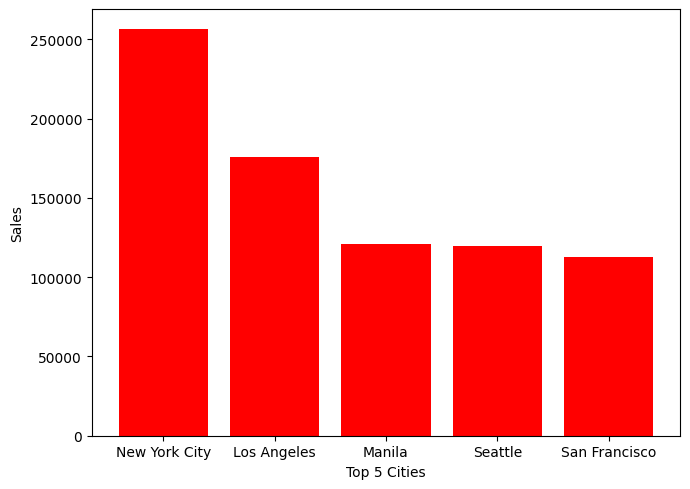

In [95]:
plt.figure(figsize=(7,5))
plt.bar(tcities1['City'] , tcities1['Sales'] ,color='Red')

plt.xlabel('Top 5 Cities')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

# Calculating Orders by ship mode

In [63]:
oship=data.groupby('Ship Mode')['Order ID'].nunique().reset_index()

In [65]:
oship = oship.rename(columns={'Order ID': 'No of Orders'})

In [66]:
oship

,Ship Mode,No of Orders
0,First Class,3821
1,Same Day,1347
2,Second Class,5119
3,Standard Class,15154


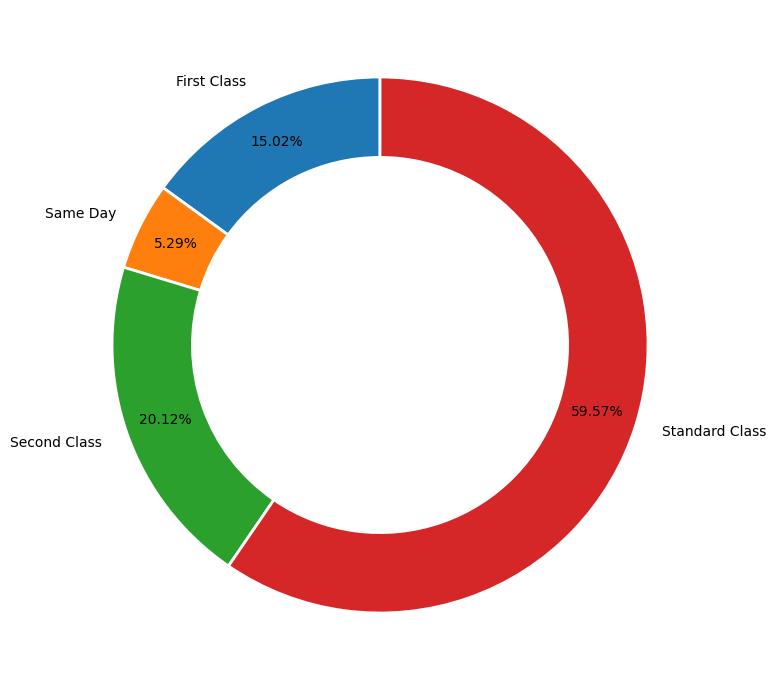

In [96]:
plt.figure(figsize=(12,7))


labels = ['First Class' , 'Same Day' , 'Second Class' , 'Standard Class']
plt.pie(oship['No of Orders'],labels=labels,autopct='%1.2f%%' ,  startangle=90, pctdistance=0.85, wedgeprops={'width': 0.3, 'edgecolor': 'white', 'linewidth': 2})

plt.tight_layout()
plt.show()

# Calculating Sales by Region

In [77]:
sreg=data.groupby('Region')['Sales'].sum().reset_index()

In [78]:
sreg

,Region,Sales
0,Africa,7.837732e+05
1,Canada,6.692817e+04
2,Caribbean,3.242809e+05
3,Central,2.822303e+06
4,Central Asia,7.528266e+05
5,EMEA,8.061613e+05
6,East,6.787812e+05
7,North,1.248166e+06
8,North Asia,8.483098e+05
9,Oceania,1.100185e+06


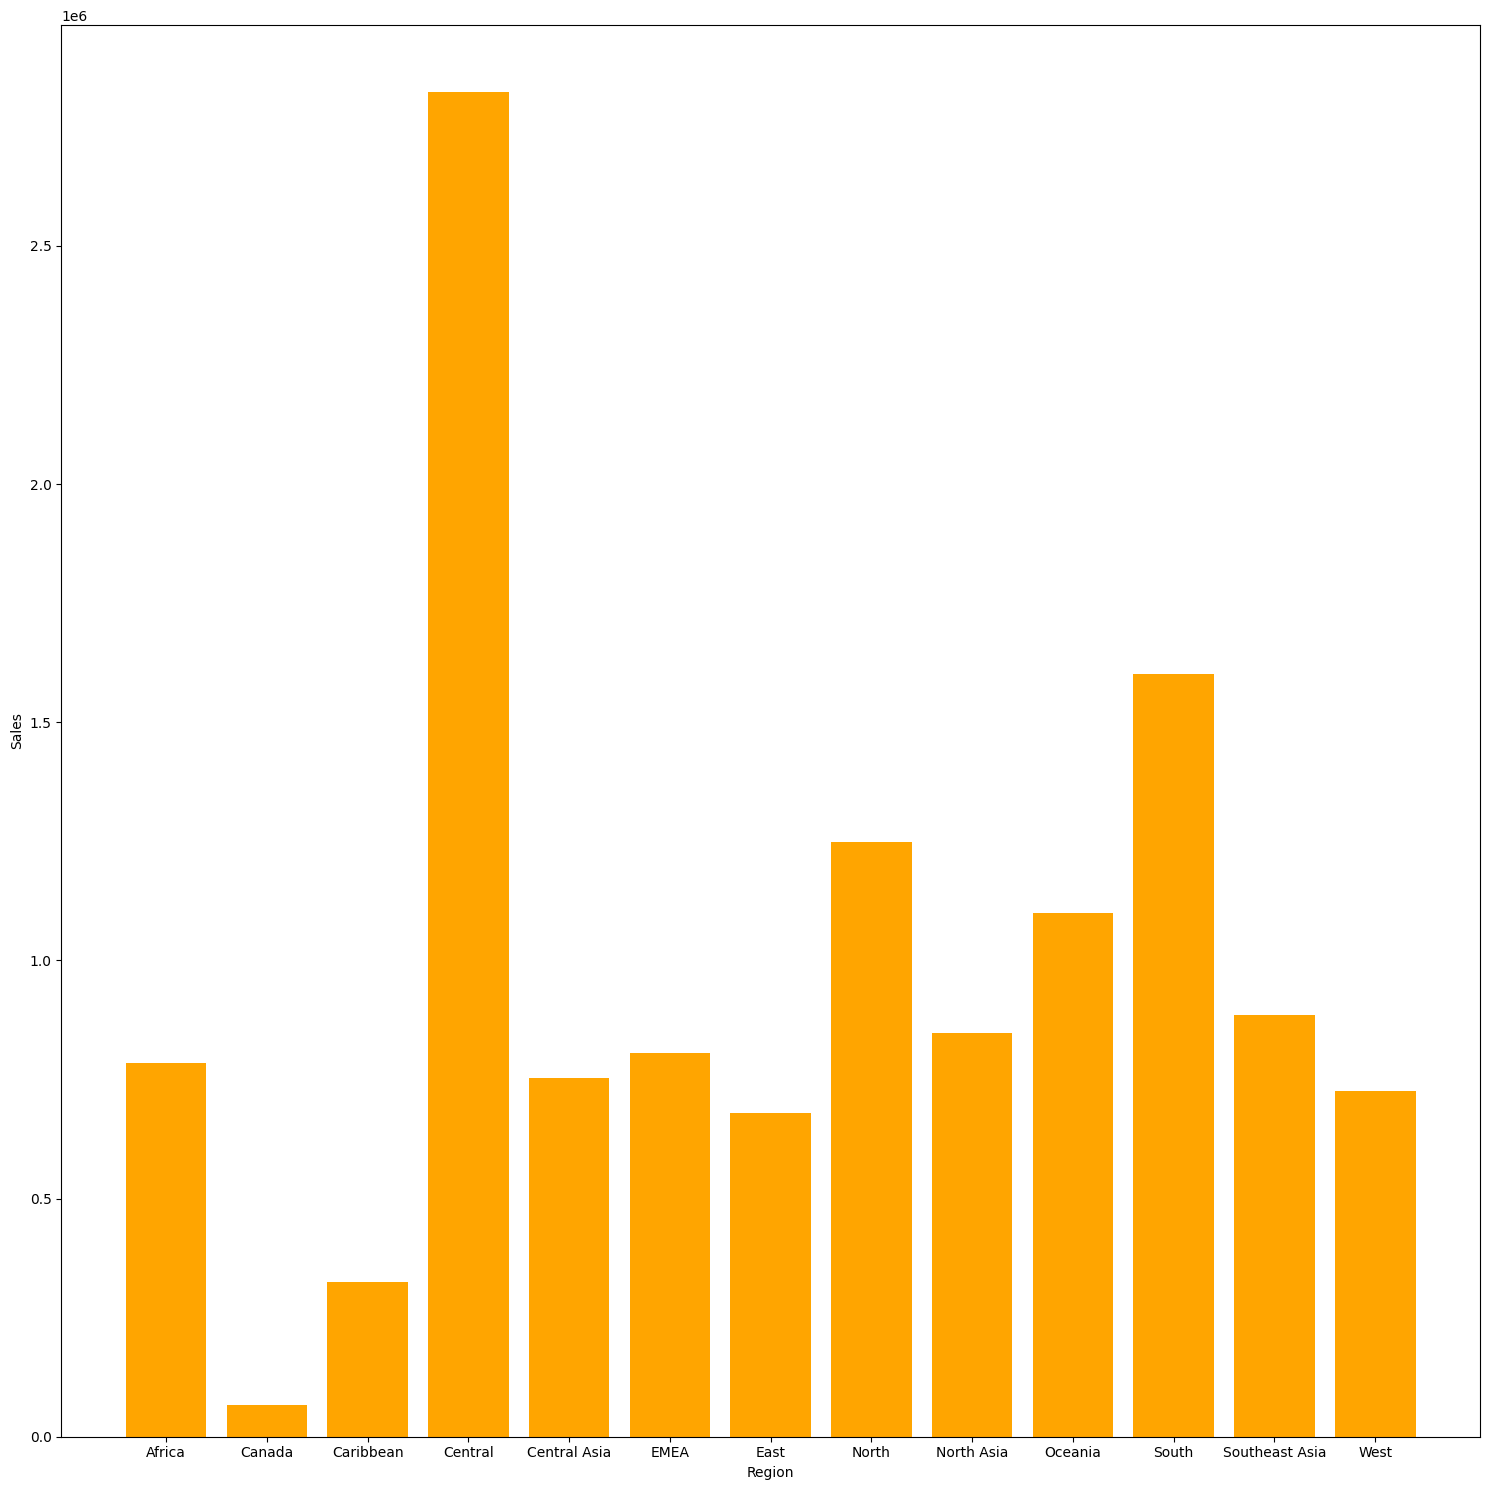

In [97]:
plt.figure(figsize=(15,15))
graph3=plt.bar(sreg['Region'] , sreg['Sales'] , color='Orange')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.savefig('Sales By Region')
plt.tight_layout()
plt.show()